<a href="https://colab.research.google.com/github/kunalssharma125-pixe/machinelearning1/blob/main/ML_PROJECT_HOUSE_PRICE_PREDICTION_Project%20FINAL%20.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
 # BASIC LIBRARIES
import numpy as np   # Used for numerical operations (arrays, calculations)
import pandas as pd  # Used to load and handle dataset (CSV files, tables)

#  VISUALIZATION LIBRARIES
import matplotlib.pyplot as plt  # Used to create basic graphs (line, bar, histogram)
import seaborn as sns            # Used for advanced visualization (heatmaps, correlations)

#  DATA PREPROCESSING
from sklearn.model_selection import train_test_split

# Used to split dataset into training and testing data
from sklearn.preprocessing import LabelEncoder, StandardScaler
# LabelEncoder → converts categorical data (text) into numerical form
# StandardScaler → scales data so all values are in similar range

from sklearn.impute import SimpleImputer
# Used to handle missing values (fill NaN with mean/median/most frequent)

# MACHINE LEARNING MODELS
from sklearn.linear_model import LinearRegression
# Simple regression model to predict continuous values (like price)

from sklearn.ensemble import RandomForestRegressor
# Advanced model using multiple decision trees for better accuracy

#  MODEL EVALUATION
from sklearn.metrics import mean_squared_error, r2_score
# mean_squared_error → checks error between predicted and actual values
# r2_score → tells how well the model fits the data (accuracy measure)


Load Dataset

In [ ]:
df = pd.read_csv("House Price Prediction Dataset.csv")
df

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage,Price
0,1,1360,5,4,3,1970,Downtown,Excellent,No,149919
1,2,4272,5,4,3,1958,Downtown,Excellent,No,424998
2,3,3592,2,2,3,1938,Downtown,Good,No,266746
3,4,966,4,2,2,1902,Suburban,Fair,Yes,244020
4,5,4926,1,4,2,1975,Downtown,Fair,Yes,636056
...,...,...,...,...,...,...,...,...,...,...
1995,1996,4994,5,4,3,1923,Suburban,Poor,No,295620
1996,1997,3046,5,2,1,2019,Suburban,Poor,Yes,580929
1997,1998,1062,5,1,2,1903,Rural,Poor,No,476925
1998,1999,4062,3,1,2,1936,Urban,Excellent,Yes,161119


BASIC CHECK

In [ ]:
df.head()     # view data

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage,Price
0,1,1360,5,4,3,1970,Downtown,Excellent,No,149919
1,2,4272,5,4,3,1958,Downtown,Excellent,No,424998
2,3,3592,2,2,3,1938,Downtown,Good,No,266746
3,4,966,4,2,2,1902,Suburban,Fair,Yes,244020
4,5,4926,1,4,2,1975,Downtown,Fair,Yes,636056


In [ ]:
df.info()     # check data types & missing value


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Id         2000 non-null   int64 
 1   Area       2000 non-null   int64 
 2   Bedrooms   2000 non-null   int64 
 3   Bathrooms  2000 non-null   int64 
 4   Floors     2000 non-null   int64 
 5   YearBuilt  2000 non-null   int64 
 6   Location   2000 non-null   object
 7   Condition  2000 non-null   object
 8   Garage     2000 non-null   object
 9   Price      2000 non-null   int64 
dtypes: int64(7), object(3)
memory usage: 156.4+ KB


In [ ]:
df.isnull()   # CHECK THAT IS THERE ANY NULL VALUE IN DATA OR NOT

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage,Price
0,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...
1995,False,False,False,False,False,False,False,False,False,False
1996,False,False,False,False,False,False,False,False,False,False
1997,False,False,False,False,False,False,False,False,False,False
1998,False,False,False,False,False,False,False,False,False,False


In [ ]:
df.describe()

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Price
count,2000.000000,2000.000000,2000.000000,2000.00000,2000.000000,2000.000000,2000.000000
mean,1000.500000,2786.209500,3.003500,2.55250,1.993500,1961.446000,537676.855000
std,577.494589,1295.146799,1.424606,1.10899,0.809188,35.926695,276428.845719
min,1.000000,501.000000,1.000000,1.00000,1.000000,1900.000000,50005.000000
25%,500.750000,1653.000000,2.000000,2.00000,1.000000,1930.000000,300098.000000
50%,1000.500000,2833.000000,3.000000,3.00000,2.000000,1961.000000,539254.000000
75%,1500.250000,3887.500000,4.000000,4.00000,3.000000,1993.000000,780086.000000
max,2000.000000,4999.000000,5.000000,4.00000,3.000000,2023.000000,999656.000000


In [ ]:
df.tail()

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage,Price
1995,1996,4994,5,4,3,1923,Suburban,Poor,No,295620
1996,1997,3046,5,2,1,2019,Suburban,Poor,Yes,580929
1997,1998,1062,5,1,2,1903,Rural,Poor,No,476925
1998,1999,4062,3,1,2,1936,Urban,Excellent,Yes,161119
1999,2000,2989,5,1,3,1903,Suburban,Fair,No,482525


In [ ]:
df.shape

(2000, 10)

DROP UNNECESSARY COLUMN

In [ ]:
if 'Id' in df.columns:
    df = df.drop('Id', axis=1)

HANDLE MISSING VALUES

In [ ]:
# Fill numerical columns with mean
df.fillna(df.mean(numeric_only=True), inplace=True)

# Fill categorical columns with most frequent value
df.fillna(df.mode().iloc[0], inplace=True)

Check Duplicates

In [ ]:
df.duplicated().sum()

np.int64(0)

Remove Duplicates

In [ ]:
df.drop_duplicates(inplace=True)

CORRELATION MATRIX


In [ ]:
import pandas as pd   # correlation matrix

# Load CSV file
df = pd.read_csv("House Price Prediction Dataset.csv")

# Show columns
print("Columns in dataset:\n", df.columns)

# Drop unnecessary column
df.drop("Id", axis=1, inplace=True)

# Convert categorical data to numeric
df = pd.get_dummies(df, drop_first=True)

# Set target column
target = "Price"

# Calculate correlation matrix
corr = df.corr(numeric_only=True)

# Check if target exists
if target not in corr.columns:
    print(f"\nError: '{target}' column not found in dataset!")
else:
    print("\nCorrelation values with", target)
    print(corr[target].sort_values(ascending=False))

    # Remove self-correlation
    corr_values = corr[target].drop(target)

    # Count positive and negative correlations
    positive = (corr_values > 0).sum()
    negative = (corr_values < 0).sum()

    print("\nSummary:")
    if positive > negative:
        print("Dataset shows more POSITIVE correlation")
    elif negative > positive:
        print("Dataset shows more NEGATIVE correlation")
    else:
        print("Dataset has balanced or NO clear correlation")

Columns in dataset:
 Index(['Id', 'Area', 'Bedrooms', 'Bathrooms', 'Floors', 'YearBuilt',
       'Location', 'Condition', 'Garage', 'Price'],
      dtype='object')

Correlation values with Price
Price                1.000000
Floors               0.055890
Condition_Fair       0.049218
Location_Suburban    0.040303
YearBuilt            0.004845
Garage_Yes           0.002842
Location_Rural       0.001890
Area                 0.001542
Bedrooms            -0.003471
Bathrooms           -0.015737
Condition_Good      -0.017179
Condition_Poor      -0.018437
Location_Urban      -0.038312
Name: Price, dtype: float64

Summary:
Dataset shows more POSITIVE correlation


In [ ]:
import pandas as pd

# Load dataset
df = pd.read_csv("House Price Prediction Dataset.csv")

# Drop unnecessary column
df.drop("Id", axis=1, inplace=True)

# Convert categorical data into numeric
df = pd.get_dummies(df, drop_first=True)

# Correlation matrix
corr_matrix = df.corr(numeric_only=True)

print(corr_matrix)

                       Area  Bedrooms  Bathrooms    Floors  YearBuilt  \
Area               1.000000  0.047523   0.021881  0.017749  -0.011609   
Bedrooms           0.047523  1.000000  -0.011990  0.010435  -0.014125   
Bathrooms          0.021881 -0.011990   1.000000  0.029089  -0.000839   
Floors             0.017749  0.010435   0.029089  1.000000  -0.006474   
YearBuilt         -0.011609 -0.014125  -0.000839 -0.006474   1.000000   
Price              0.001542 -0.003471  -0.015737  0.055890   0.004845   
Location_Rural    -0.017328 -0.011276  -0.020028 -0.007149  -0.009179   
Location_Suburban  0.003404 -0.010409  -0.000904 -0.009907  -0.004632   
Location_Urban     0.000010  0.025640  -0.007326  0.014640  -0.029859   
Condition_Fair     0.012805  0.002541  -0.029646 -0.000864  -0.039087   
Condition_Good     0.001289 -0.008847   0.021735  0.001462   0.022457   
Condition_Poor    -0.003387  0.010673   0.013355  0.017469   0.020892   
Garage_Yes        -0.003441 -0.041713   0.004057 -0

Categorical Feature Distribution



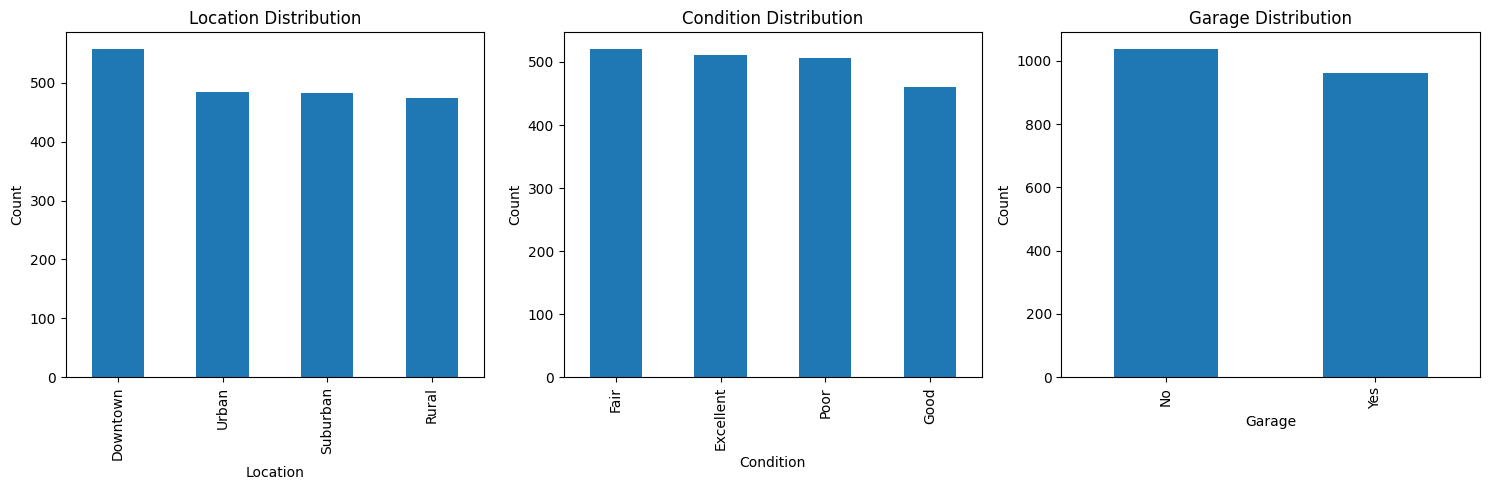

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("House Price Prediction Dataset.csv")

# Columns to visualize (categorical ones)
columns = ['Location', 'Condition', 'Garage']

# Create subplots
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes = axes.flatten()

# Plot bar charts
for i, col in enumerate(columns):
    df[col].value_counts().plot(kind='bar', ax=axes[i])
    axes[i].set_title(f'{col} Distribution')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')

plt.tight_layout()
plt.show()

Categorical Feature Distribution using Pie Chart

   Id  Area  Bedrooms  Bathrooms  Floors  YearBuilt  Location  Condition  \
0   1  1360         5          4       3       1970  Downtown  Excellent   
1   2  4272         5          4       3       1958  Downtown  Excellent   
2   3  3592         2          2       3       1938  Downtown       Good   
3   4   966         4          2       2       1902  Suburban       Fair   
4   5  4926         1          4       2       1975  Downtown       Fair   

  Garage   Price  
0     No  149919  
1     No  424998  
2     No  266746  
3    Yes  244020  
4    Yes  636056  
Index(['Id', 'Area', 'Bedrooms', 'Bathrooms', 'Floors', 'YearBuilt',
       'Location', 'Condition', 'Garage', 'Price'],
      dtype='object')


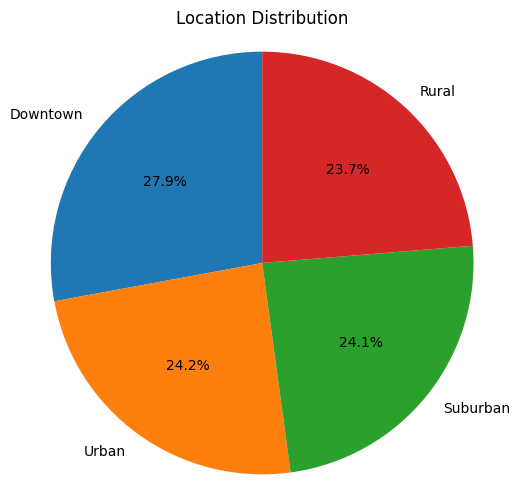

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("House Price Prediction Dataset.csv")

# Show basic info
print(df.head())
print(df.columns)

# Choose a categorical column (example: Location)
counts = df['Location'].value_counts()

# Plot pie chart
plt.figure(figsize=(6,6))
plt.pie(counts.values, labels=counts.index, autopct='%1.1f%%', startangle=90)

plt.title('Location Distribution')
plt.axis('equal')
plt.show()

House Condition Distribution using Pie Chart

   Id  Area  Bedrooms  Bathrooms  Floors  YearBuilt  Location  Condition  \
0   1  1360         5          4       3       1970  Downtown  Excellent   
1   2  4272         5          4       3       1958  Downtown  Excellent   
2   3  3592         2          2       3       1938  Downtown       Good   
3   4   966         4          2       2       1902  Suburban       Fair   
4   5  4926         1          4       2       1975  Downtown       Fair   

  Garage   Price  
0     No  149919  
1     No  424998  
2     No  266746  
3    Yes  244020  
4    Yes  636056  
Index(['Id', 'Area', 'Bedrooms', 'Bathrooms', 'Floors', 'YearBuilt',
       'Location', 'Condition', 'Garage', 'Price'],
      dtype='object')


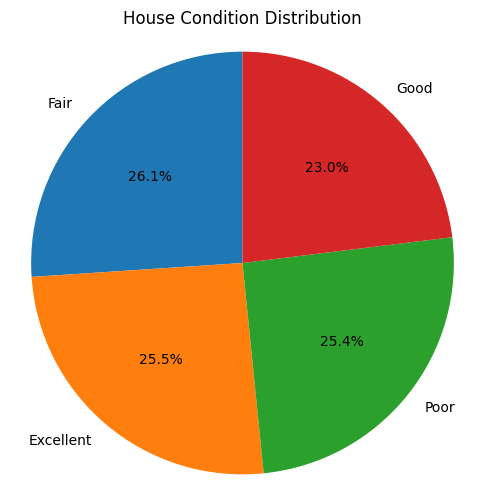

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv('House Price Prediction Dataset.csv')

print(df.head())
print(df.columns)

# Choose a valid categorical column
counts = df['Condition'].value_counts()

# Plot pie chart
plt.figure(figsize=(6,6))
plt.pie(counts.values, labels=counts.index, autopct='%1.1f%%', startangle=90)
plt.title('House Condition Distribution')
plt.axis('equal')
plt.show()

Correlation Heatmap of House Price Dataset

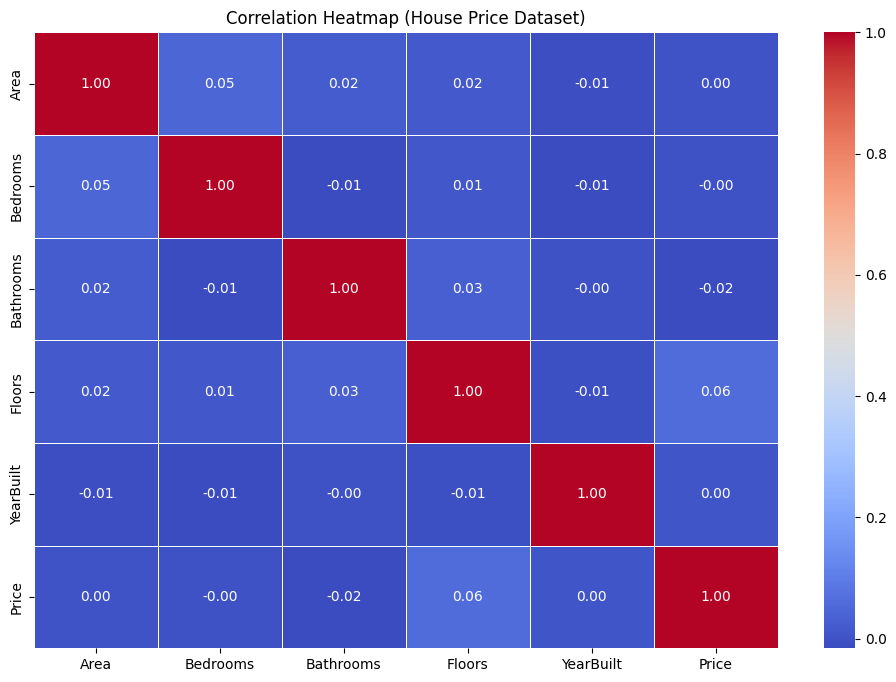

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("House Price Prediction Dataset.csv")

# Drop unnecessary column
df.drop("Id", axis=1, inplace=True)

# Convert categorical data into numeric
df = pd.get_dummies(df, drop_first=True)

# Select only numeric columns
numeric_df = df.select_dtypes(include=['int64', 'float64'])

# Compute correlation matrix
corr = numeric_df.corr()

# Plot heatmap
plt.figure(figsize=(12, 8))

sns.heatmap(
    corr,
    annot=True,          # show values inside boxes
    fmt=".2f",           # 2 decimal places
    cmap="coolwarm",     # blue-red color
    linewidths=0.5
)

plt.title("Correlation Heatmap (House Price Dataset)")
plt.show()

House Price Distribution by Condition (Box Plot)

/tmp/ipykernel_5606/107453402.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = plt.boxplot(groups, labels=groups.index, patch_artist=True)


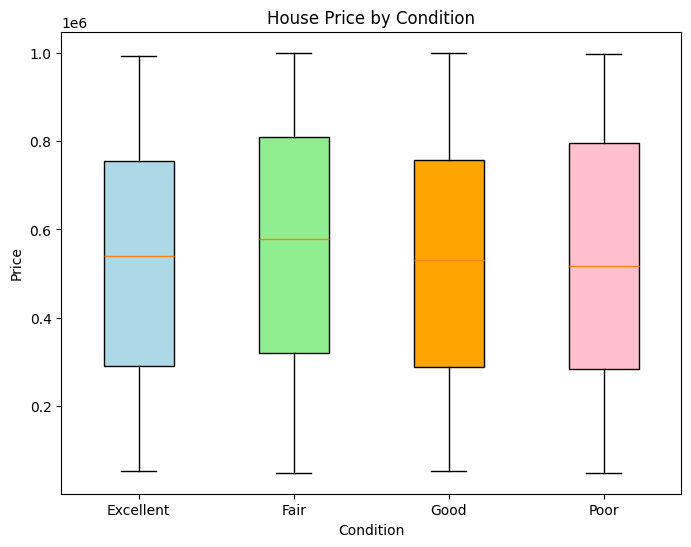

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("House Price Prediction Dataset.csv")

# Group data (categorical vs price)
groups = df.groupby('Condition')['Price'].apply(list)

plt.figure(figsize=(8,6))

box = plt.boxplot(groups, labels=groups.index, patch_artist=True)

# Add different colors
colors = ['lightblue', 'lightgreen', 'orange', 'pink']

for patch, color in zip(box['boxes'], colors):
    patch.set_facecolor(color)

plt.title('House Price by Condition')
plt.xlabel('Condition')
plt.ylabel('Price')
plt.show()

Outlier Removal using IQR Method (House Price Dataset)

In [ ]:
import pandas as pd

# Load the dataset
df = pd.read_csv("House Price Prediction Dataset.csv")

# Select the column to filter
column_name = 'Price'

# 1. Calculate Q1 (25th percentile) and Q3 (75th percentile)
Q1 = df[column_name].quantile(0.25)
Q3 = df[column_name].quantile(0.75)

# 2. Calculate the Interquartile Range (IQR)
IQR = Q3 - Q1

# 3. Define the upper and lower bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# 4. Filter the DataFrame to remove outliers
df_cleaned = df[(df[column_name] >= lower_bound) & (df[column_name] <= upper_bound)]

# Verification
print(f"Original number of records: {len(df)}")
print(f"Number of records after removing outliers: {len(df_cleaned)}")
print(f"Outliers removed: {len(df) - len(df_cleaned)}")

# Save the cleaned dataset
df_cleaned.to_csv("house_price_cleaned.csv", index=False)

Original number of records: 2000
Number of records after removing outliers: 2000
Outliers removed: 0


Feature Scaling using Min-Max Normalization

In [49]:
from sklearn.model_selection import train_test_split

X = df.drop('Price', axis=1)
y = df['Price']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
# Show original price range
print(f"Original Price Range → min: {y.min()}, max: {y.max()}")

# Show scaled feature range
print(f"Scaled Features Range → min: {X_train_scaled.min():.2f}, max: {X_train_scaled.max():.2f}")
print(f"Shape: Rows = {X_train_scaled.shape[0]}, Columns = {X_train_scaled.shape[1]}")

Original Price Range → min: 50005, max: 999656
Scaled Features Range → min: 0.00, max: 1.00
Shape: Rows = 1600, Columns = 13


House Price Prediction using Linear Regression

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# 1. Load the data
df = pd.read_csv("House Price Prediction Dataset.csv")

# 2. Select Features (X) and Target (y)
# We want to predict 'Price'
y = df['Price']

# Select relevant features
features = ['Area', 'Bedrooms', 'Bathrooms', 'Floors', 'YearBuilt', 'Location', 'Condition', 'Garage']
X = df[features]

# 3. Handle Categorical Data
X = pd.get_dummies(X, columns=['Location', 'Condition', 'Garage'], drop_first=True)

# 4. Split the data into Training and Testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 5. Initialize and Train the Linear Regression Model
model = LinearRegression()
model.fit(X_train, y_train)

# 6. Make Predictions on the test set
y_pred = model.predict(X_test)

# 7. Evaluate the Model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Linear Regression Results:")
print("-" * 25)
print(f"Mean Squared Error (MSE): {mse:,.2f}")
print(f"R-squared (R2) Score: {r2:.4f}")

# Optional: Feature importance (coefficients)
print("\nFeature Coefficients:")
coefficients = pd.DataFrame({'Feature': X.columns, 'Coefficient': model.coef_})
print(coefficients.sort_values(by='Coefficient', ascending=False))

Linear Regression Results:
-------------------------
Mean Squared Error (MSE): 78,321,466,146.03
R-squared (R2) Score: -0.0067

Feature Coefficients:
              Feature   Coefficient
8      Condition_Fair  24083.307846
3              Floors  23727.983633
6   Location_Suburban  11511.989815
10     Condition_Poor   4073.268930
11         Garage_Yes   2373.530579
5      Location_Rural   1317.542020
4           YearBuilt    117.613885
1            Bedrooms     76.784827
0                Area     -0.575754
2           Bathrooms  -9662.248234
7      Location_Urban -12718.918912
9      Condition_Good -12941.044835


Linear Regression Equation for House Price Prediction

In [ ]:
import pandas as pd
from sklearn.linear_model import LinearRegression

# --- 1. Quick Setup ---
df = pd.read_csv("House Price Prediction Dataset.csv")

# Target
y = df['Price']

# Using fewer features for a clean equation
features = ['Area', 'Bedrooms']
X = df[features]

# --- 2. Train the Model ---
model = LinearRegression()
model.fit(X, y)

# --- 3. Find the Equation ---
# Intercept (base price)
intercept = model.intercept_

# Coefficients (impact of each feature)
coefficients = model.coef_

# Build equation
equation = f"Predicted_Price = {intercept:,.2f}"

for i, feature_name in enumerate(X.columns):
    coef_value = coefficients[i]
    sign = "+" if coef_value >= 0 else "-"
    equation += f" {sign} ({abs(coef_value):,.2f} * {feature_name})"

print("Linear Regression Equation:")
print("-" * 40)
print(equation)

Linear Regression Equation:
----------------------------------------
Predicted_Price = 538,729.40 + (0.37 * Area) - (689.19 * Bedrooms)


House Price Prediction using Linear Regression (After Data Cleaning)

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn import metrics

# Load dataset (cleaned one after outlier removal)
df = pd.read_csv("house_price_cleaned.csv")

# Convert categorical to numeric
df = pd.get_dummies(df, drop_first=True)

# Define features (X) and target (y)
X = df.drop('Price', axis=1)
y = df['Price']

# Split data into training and testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Create model
model = LinearRegression()

# Train model
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Evaluate model
print("Mean Absolute Error:", metrics.mean_absolute_error(y_test, y_pred))
print("R2 Score:", metrics.r2_score(y_test, y_pred))

Mean Absolute Error: 242867.44926338628
R2 Score: -0.006181784611834162


Regression Analysis using Most Correlated Feature

In [ ]:
import pandas as pd

# Load dataset
df = pd.read_csv("house_price_cleaned.csv")

# Convert categorical to numeric
df = pd.get_dummies(df, drop_first=True)

# Find correlation with Price
corr = df.corr(numeric_only=True)['Price'].sort_values(ascending=False)

print("Correlation with Price:\n")
print(corr)

Correlation with Price:

Price                1.000000
Floors               0.055890
Condition_Fair       0.049218
Location_Suburban    0.040303
YearBuilt            0.004845
Garage_Yes           0.002842
Location_Rural       0.001890
Area                 0.001542
Bedrooms            -0.003471
Bathrooms           -0.015737
Condition_Good      -0.017179
Condition_Poor      -0.018437
Id                  -0.025643
Location_Urban      -0.038312
Name: Price, dtype: float64


Linear Regression Analysis using Highest Correlated Feature (Floors)

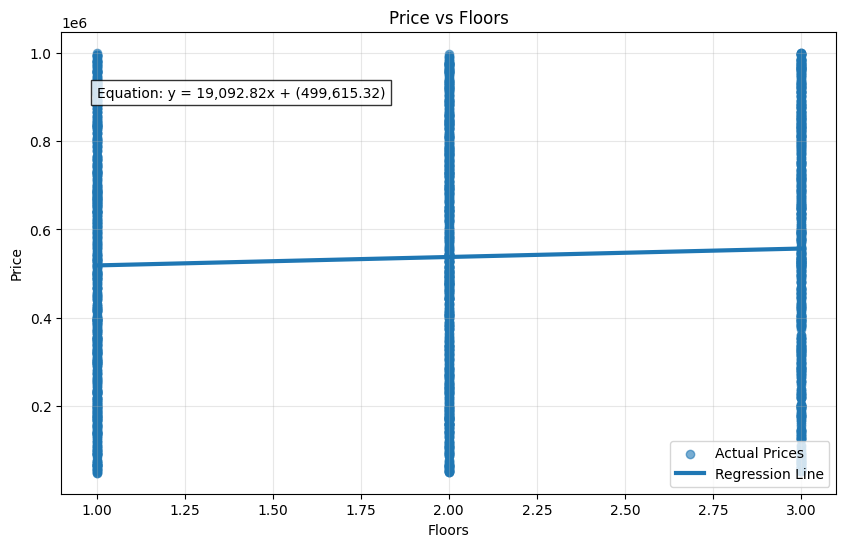

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LinearRegression

# Use best feature
feature = 'Floors'

X = df[[feature]].values
y = df['Price'].values

# Train model
model = LinearRegression()
model.fit(X, y)

m = model.coef_[0]
c = model.intercept_

# Plot
plt.figure(figsize=(10,6))

plt.scatter(X, y, alpha=0.6, label='Actual Prices')

x_range = np.array([X.min(), X.max()])
y_range = m * x_range + c

plt.plot(x_range, y_range, linewidth=3, label='Regression Line')

plt.title('Price vs Floors')
plt.xlabel('Floors')
plt.ylabel('Price')

equation = f'y = {m:,.2f}x + ({c:,.2f})'
plt.text(X.min(), y.max()*0.9, f'Equation: {equation}',
         bbox=dict(facecolor='white', alpha=0.8))

plt.legend()
plt.grid(alpha=0.3)

plt.show()

House Price Prediction using Random Forest Regression

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# Load original dataset
df = pd.read_csv("House Price Prediction Dataset.csv")

# Drop unnecessary column
df.drop("Id", axis=1, inplace=True)

# Convert categorical data
df = pd.get_dummies(df, drop_first=True)

# Features & Target
X = df.drop('Price', axis=1)
y = df['Price']

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Model
model = RandomForestRegressor(n_estimators=100, random_state=42)

# Train
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Evaluation
print("Random Forest Results:")
print("MAE:", mean_absolute_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

Random Forest Results:
MAE: 252518.030125
R2 Score: -0.09640442128237403


Feature Importance Analysis (Random Forest)

     Feature  Importance
0       Area    0.323898
4  YearBuilt    0.262667
1   Bedrooms    0.094241
2  Bathrooms    0.071979
3     Floors    0.047900


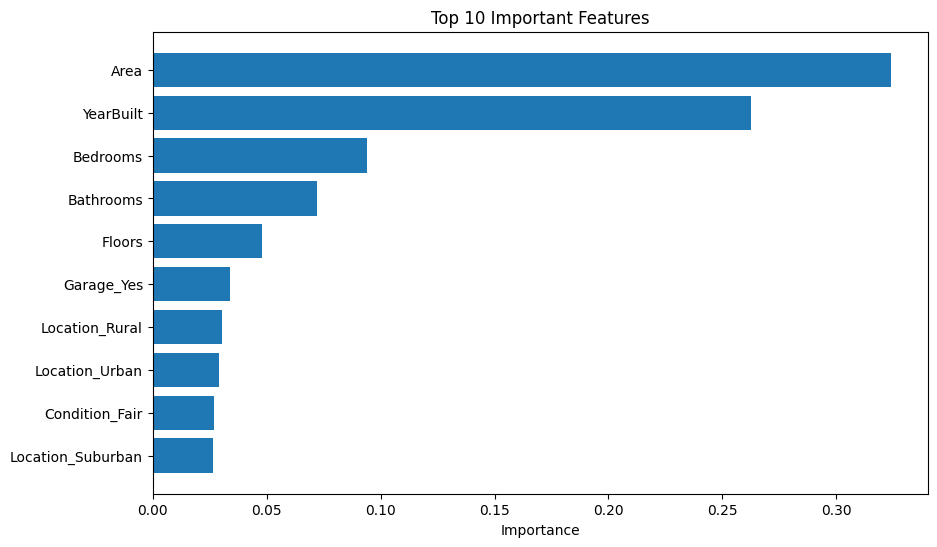

In [ ]:
import matplotlib.pyplot as plt

# Get importance
importance = model.feature_importances_

# Convert to DataFrame
feat_imp = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importance
}).sort_values(by='Importance', ascending=False)

print(feat_imp.head())

# Plot
plt.figure(figsize=(10,6))
plt.barh(feat_imp['Feature'][:10], feat_imp['Importance'][:10])
plt.xlabel("Importance")
plt.title("Top 10 Important Features")
plt.gca().invert_yaxis()
plt.show()

Actual vs Predicted Price Comparison (Random Forest)

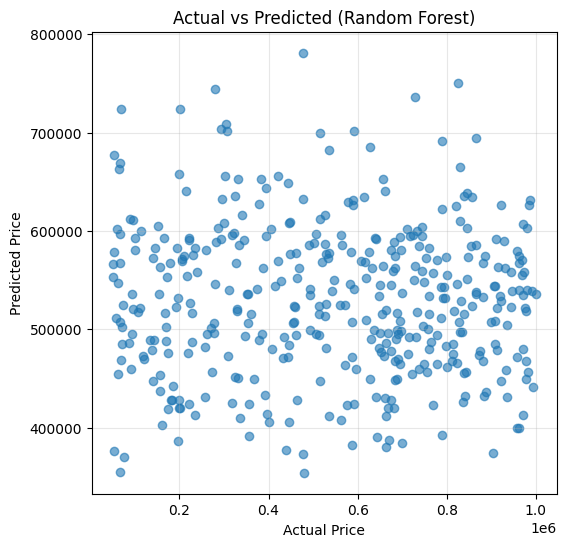

In [ ]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.6)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted (Random Forest)")

plt.grid(alpha=0.3)
plt.show()

Hyperparameter Tuning using Random Forest (Grid Search)

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score

# Load dataset
df = pd.read_csv("House Price Prediction Dataset.csv")

# Drop Id
df.drop("Id", axis=1, inplace=True)

# Convert categorical data
df = pd.get_dummies(df, drop_first=True)

# Features & Target
X = df.drop('Price', axis=1)
y = df['Price']

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Define model
rf = RandomForestRegressor(random_state=42)

# Hyperparameters to tune
param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5]
}

# Grid Search
grid = GridSearchCV(rf, param_grid, cv=3, scoring='r2')
grid.fit(X_train, y_train)

# Best model
best_model = grid.best_estimator_

# Prediction
y_pred = best_model.predict(X_test)

# Evaluation
print("Best Parameters:", grid.best_params_)
print("R2 Score after tuning:", r2_score(y_test, y_pred))

Best Parameters: {'max_depth': 5, 'min_samples_split': 5, 'n_estimators': 100}
R2 Score after tuning: -0.017046129531260057


Model Comparison: Linear Regression vs Random Forest

In [ ]:
# Linear Regression
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
lr_pred = lr_model.predict(X_test)
lr_r2 = r2_score(y_test, lr_pred)

# Random Forest
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)
rf_r2 = r2_score(y_test, rf_pred)

# Comparison
print("\nModel Comparison:")
print("-----------------")
print(f"Linear Regression R2: {lr_r2}")
print(f"Random Forest R2: {rf_r2}")


Model Comparison:
-----------------
Linear Regression R2: -0.006717808430749761
Random Forest R2: -0.09640442128237403


Model Comparison using Actual vs Predicted Scatter Plot

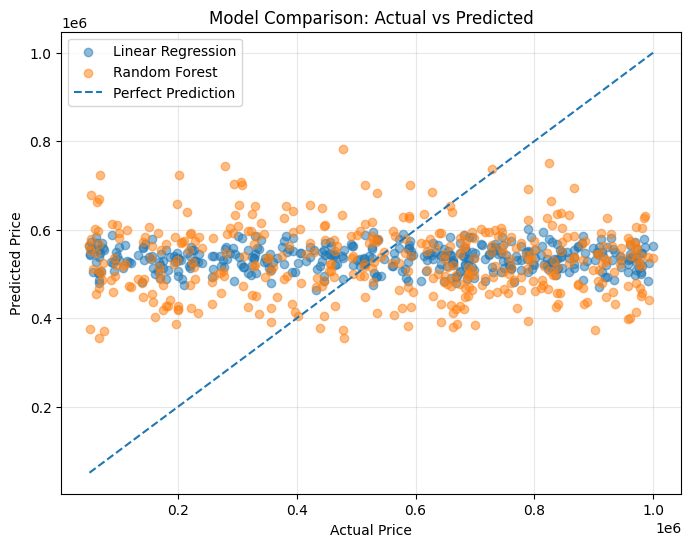

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

# Linear Regression
plt.scatter(y_test, lr_pred, alpha=0.5, label='Linear Regression')

# Random Forest
plt.scatter(y_test, rf_pred, alpha=0.5, label='Random Forest')

# Perfect line
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         linestyle='--', label='Perfect Prediction')

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Model Comparison: Actual vs Predicted")

plt.legend()
plt.grid(alpha=0.3)
plt.show()

Classification Analysis for Evaluation (Accuracy & Confusion Matrix)


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Load dataset
df = pd.read_csv("House Price Prediction Dataset.csv")

# Drop Id
df.drop("Id", axis=1, inplace=True)

# Convert categorical data
df = pd.get_dummies(df, drop_first=True)

# Create binary target (High vs Low price)
df['high_price'] = df['Price'].apply(lambda x: 1 if x > df['Price'].median() else 0)

# Features & Target
X = df.drop(['Price', 'high_price'], axis=1)
y = df['high_price']

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Use Random Forest (classification version)
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Prediction
y_pred = model.predict(X_test)

# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.49

Confusion Matrix:
 [[104  86]
 [118  92]]

Classification Report:
               precision    recall  f1-score   support

           0       0.47      0.55      0.50       190
           1       0.52      0.44      0.47       210

    accuracy                           0.49       400
   macro avg       0.49      0.49      0.49       400
weighted avg       0.49      0.49      0.49       400

